### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GPT_4_MINI_API_KEY"]=os.getenv("GPT_4_MINI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [7]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

messages=[
    AIMessage(content=f"How can I help you?", name="LLMmodel")
]
messages.append(HumanMessage(content=f"I want to learn coding.", name="Pavan"))
messages.append(AIMessage(content=f"Which Programming Language are you interested in?", name="LLMmodel"))
messages.append(HumanMessage(content=f"I want to learn Python", name="Pavan"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: LLMmodel

How can I help you?
================================ Human Message =================================
Name: Pavan

I want to learn coding.
================================== Ai Message ==================================
Name: LLMmodel

Which Programming Language are you interested in?
================================ Human Message =================================
Name: Pavan

I want to learn Python


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [8]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API_KEY"))
result=llm.invoke(messages)

In [ ]:
result.response_metadata[[][[[[[[[[[[[[[[[]]]]]]]]]]]]]]]]

{'token_usage': {'completion_tokens': 451,
  'prompt_tokens': 75,
  'total_tokens': 526,
  'completion_time': 0.634797896,
  'completion_tokens_details': None,
  'prompt_time': 0.010911401,
  'prompt_tokens_details': None,
  'queue_time': 0.061974565,
  'total_time': 0.645709297},
 'model_name': 'llama-3.1-8b-instant',
 'system_fingerprint': 'fp_d317489708',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [10]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [12]:
llm_with_tools = llm.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"Add 2 and 3", name="Pavan")])

In [14]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 3},
  'id': '0jcg0cvee',
  'type': 'tool_call'}]

### Using messages as state

In [30]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
class State(TypedDict):
    # messages: list[HumanMessage | AIMessage] or 
    messages: list[AnyMessage]

#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [32]:
from langgraph.graph.message import add_messages
from typing import Annotated
from pydantic import BaseModel

class State(BaseModel):
    # messages: Annotated[list[HumanMessage | AIMessage], add_messages] or 
    messages: Annotated[list[AnyMessage], add_messages]

### Reducers with add_messages

In [33]:
initial_messages=[AIMessage(content=f"How can I help you?", name="LLMmodel")]
initial_messages.append(HumanMessage(content=f"I need learn coding.", name="Pavan"))
initial_messages

[AIMessage(content='How can I help you?', additional_kwargs={}, response_metadata={}, name='LLMmodel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I need learn coding.', additional_kwargs={}, response_metadata={}, name='Pavan')]

In [34]:
ai_message=AIMessage(content=f"Which programming language are you interested in?", name="LLMmodel")
ai_message

AIMessage(content='Which programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='LLMmodel', tool_calls=[], invalid_tool_calls=[])

In [35]:
#Reducers are used for append messages instead of overwrite them.
add_messages(initial_messages, ai_message)

[AIMessage(content='How can I help you?', additional_kwargs={}, response_metadata={}, name='LLMmodel', id='ae0d4ee4-c011-4851-b900-adba91e790b2', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I need learn coding.', additional_kwargs={}, response_metadata={}, name='Pavan', id='1b69ae17-0a6b-40f2-bd6f-30e390f8dc4b'),
 AIMessage(content='Which programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='LLMmodel', id='56202056-4947-4f05-85fa-b8cc4b056050', tool_calls=[], invalid_tool_calls=[])]

In [39]:
#chatbot node function
def llm_tool(state:State):
    # return {'messages':[llm_with_tools.invoke(state['messages'])]}
    return {'messages':[llm_with_tools.invoke(state.messages)]} #since we use pydantic model we can use dot notation instead of dict notation

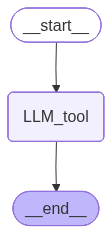

In [40]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder=StateGraph(State)

builder.add_node("LLM_tool", llm_tool)
builder.add_edge(START, "LLM_tool")
builder.add_edge("LLM_tool", END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [41]:
# invocation

messages= graph.invoke({"messages":"Add 2 and 3"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 2 and 3
================================== Ai Message ==================================
Tool Calls:
  add (ye8141k1t)
 Call ID: ye8141k1t
  Args:
    a: 2
    b: 3


In [49]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

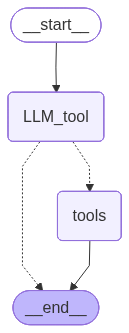

In [50]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder=StateGraph(State)

# Add nodes
builder.add_node("LLM_tool", llm_tool)
builder.add_node("tools", ToolNode(tools=[add])) #add function is defined above

## Add edges
builder.add_edge(START, "LLM_tool")
builder.add_conditional_edges(
    "LLM_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [51]:
messages= graph.invoke({"messages":"Add 2 and 3"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 2 and 3
================================== Ai Message ==================================
Tool Calls:
  add (dv7w1dcth)
 Call ID: dv7w1dcth
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5


In [52]:
messages= graph.invoke({"messages":"What is MachineLearning?"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is MachineLearning?
================================== Ai Message ==================================

<brave_search> Machine Learning 

The search results don't contain a specific definition for Machine Learning.
